MOUNT GOOGLE DRIVE


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


IMPORT REQUIRED LIBRARIES


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

LOAD DATASET FROM GOOGLE DRIVE

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/credit_card_fraud_synthetic.csv")

print("Dataset Loaded Successfully")


Dataset Loaded Successfully


DISPLAY FIRST 5 ROWS

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,Amount,Class
0,121958,-2.289061,-1.313758,-0.452562,-0.392802,0.224787,1600.89,0
1,146867,1.432482,-1.095302,-0.129910,-1.362911,-1.017335,4191.85,0
2,131932,1.214722,-0.168797,0.581433,0.699020,0.964415,3271.32,0
3,103694,-0.880864,0.110956,-0.203236,-0.243510,0.362543,1377.51,0
4,119879,-0.881879,0.786970,1.110118,0.015365,-1.135162,4838.72,0


CHECK DATASET SHAPE

In [6]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 8


 CHECK COLUMN NAMES


In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'Amount', 'Class'], dtype='object')

 2: DATA CLEANING & PREPROCESSING

CHECK MISSING VALUES

In [8]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
Amount,0
Class,0


REMOVE DUPLICATES

In [9]:
df = df.drop_duplicates()

print("Duplicates Removed")
print("New Shape :", df.shape)

Duplicates Removed
New Shape : (1000, 8)


CHECK DATA TYPES

In [10]:
df.dtypes

,0
Time,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
Amount,float64
Class,int64


FILL NULL VALUES IF PRESENT


In [11]:
df = df.fillna(df.mean(numeric_only=True))

print("Missing Values Handled")


Missing Values Handled


BASIC DATA INFORMATION

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    1000 non-null   int64  
 1   V1      1000 non-null   float64
 2   V2      1000 non-null   float64
 3   V3      1000 non-null   float64
 4   V4      1000 non-null   float64
 5   V5      1000 non-null   float64
 6   Amount  1000 non-null   float64
 7   Class   1000 non-null   int64  
dtypes: float64(6), int64(2)
memory usage: 62.6 KB


 3: DESCRIPTIVE STATISTICS

DESCRIPTIVE STATISTICS

In [13]:
df.describe()

,Time,V1,V2,V3,V4,V5,Amount,Class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,86194.539000,0.017610,0.069906,-0.022792,0.022354,-0.013218,2577.052080,0.018000
std,50008.474586,1.038301,1.035560,0.992346,0.978387,0.998908,1444.284318,0.133018
min,235.000000,-3.568205,-2.913672,-3.239438,-2.936162,-3.708797,25.890000,0.000000
25%,42052.250000,-0.646795,-0.594730,-0.693360,-0.624690,-0.711692,1358.502500,0.000000
50%,89361.500000,0.031403,0.089010,-0.008512,-0.000167,0.019587,2636.405000,0.000000
75%,127614.750000,0.742573,0.759734,0.666350,0.664478,0.686529,3849.640000,0.000000
max,172627.000000,3.174442,3.260491,2.750723,3.657702,2.840886,4998.710000,1.000000


AVERAGE TRANSACTION AMOUNT

In [14]:
avg_amount = df['Amount'].mean()

print("Average Transaction Amount :", avg_amount)

Average Transaction Amount : 2577.05208


FRAUD VS NORMAL COUNT

In [15]:
fraud_count = df['Class'].value_counts()

print(fraud_count)

Class
0    982
1     18
Name: count, dtype: int64


 FRAUD PERCENTAGE


In [16]:
fraud_percent = (df['Class'].sum()/len(df))*100

print("Fraud Percentage :", fraud_percent)

Fraud Percentage : 1.7999999999999998


4: FRAUD BEHAVIOR ANALYSIS


 FRAUD VS NORMAL TRANSACTION ANALYSIS


In [17]:
fraud = df[df['Class']==1]
normal = df[df['Class']==0]

print("Fraud Transactions :", len(fraud))
print("Normal Transactions :", len(normal))


Fraud Transactions : 18
Normal Transactions : 982


 FRAUD TRANSACTION STATISTICS

In [18]:
fraud['Amount'].describe()


,Amount
count,18.000000
mean,2381.920000
std,1134.369268
min,167.100000
25%,1479.822500
50%,2299.890000
75%,3481.960000
max,3948.910000


NORMAL TRANSACTION STATISTICS

In [19]:
normal['Amount'].describe()


,Amount
count,982.000000
mean,2580.628839
std,1449.558899
min,25.890000
25%,1357.707500
50%,2637.275000
75%,3858.762500
max,4998.710000


 5: GROUP-BASED ANALYSIS


AMOUNT VS FRAUD


In [20]:
df.groupby('Class')['Amount'].mean()

,Amount
Class,
0,2580.628839
1,2381.920000


TIME VS FRAUD


In [21]:
df.groupby('Class')['Time'].mean()


,Time
Class,
0,86270.832994
1,82032.277778


FEATURE PATTERN ANALYSIS


In [22]:
df.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,Amount
Class,,,,,,,
0,86270.832994,0.014982,0.072126,-0.01976,0.018787,-0.013382,2580.628839
1,82032.277778,0.160986,-0.051172,-0.18818,0.216924,-0.004255,2381.920000


6: RELATIONSHIP ANALYSIS


 CORRELATION MATRIX

In [23]:
correlation = df.corr()

correlation

,Time,V1,V2,V3,V4,V5,Amount,Class
Time,1.000000,0.003712,-0.014759,-0.025795,0.069737,-0.058153,0.054233,-0.011274
V1,0.003712,1.000000,0.007395,0.002214,-0.030697,0.088616,0.032516,0.018705
V2,-0.014759,0.007395,1.000000,0.061603,-0.016288,-0.035025,-0.026302,-0.015838
V3,-0.025795,0.002214,0.061603,1.000000,0.021182,0.035898,0.056290,-0.022576
V4,0.069737,-0.030697,-0.016288,0.021182,1.000000,-0.019725,-0.024785,0.026938
V5,-0.058153,0.088616,-0.035025,0.035898,-0.019725,1.000000,0.013353,0.001215
Amount,0.054233,0.032516,-0.026302,0.056290,-0.024785,0.013353,1.000000,-0.018301
Class,-0.011274,0.018705,-0.015838,-0.022576,0.026938,0.001215,-0.018301,1.000000


 TOP CORRELATED FEATURES WITH CLASS


In [24]:
correlation['Class'].sort_values(ascending=False)


,Class
Class,1.000000
V4,0.026938
V1,0.018705
V5,0.001215
Time,-0.011274
V2,-0.015838
Amount,-0.018301
V3,-0.022576


7: DATA VISUALIZATION


FRAUD DISTRIBUTION BAR CHART

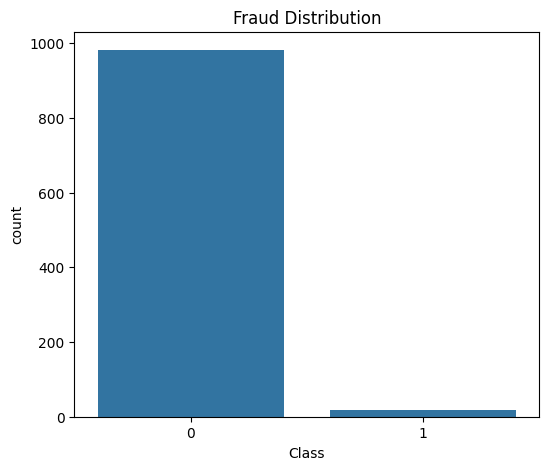

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(x='Class', data=df)

plt.title('Fraud Distribution')
plt.show()

TRANSACTION AMOUNT HISTOGRAM

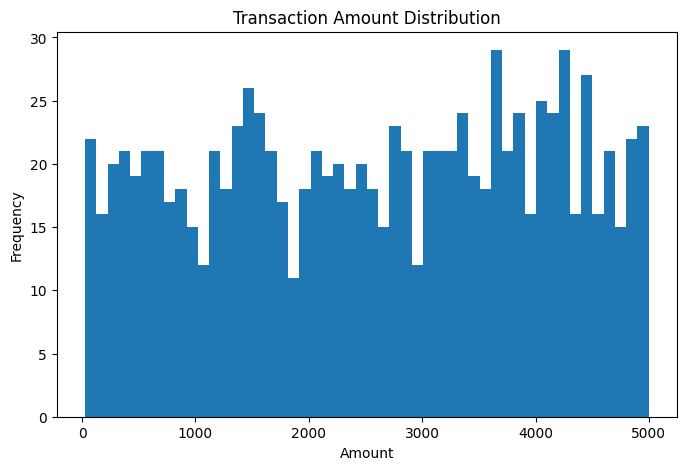

In [26]:
plt.figure(figsize=(8,5))

plt.hist(df['Amount'], bins=50)

plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.show()

 SCATTER PLOT

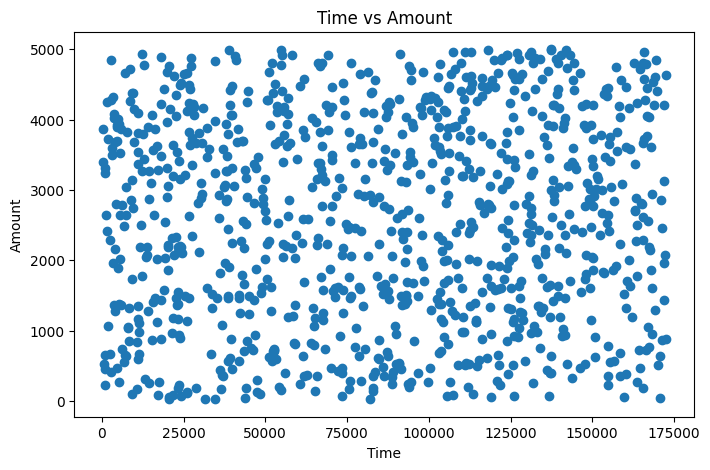

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(df['Time'], df['Amount'])

plt.title('Time vs Amount')
plt.xlabel('Time')
plt.ylabel('Amount')

plt.show()

BOXPLOT FOR OUTLIER DETECTION


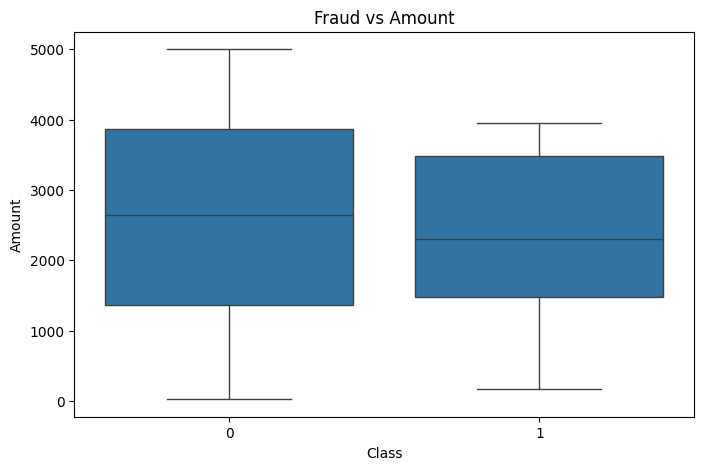

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Fraud vs Amount')

plt.show()

 HEATMAP


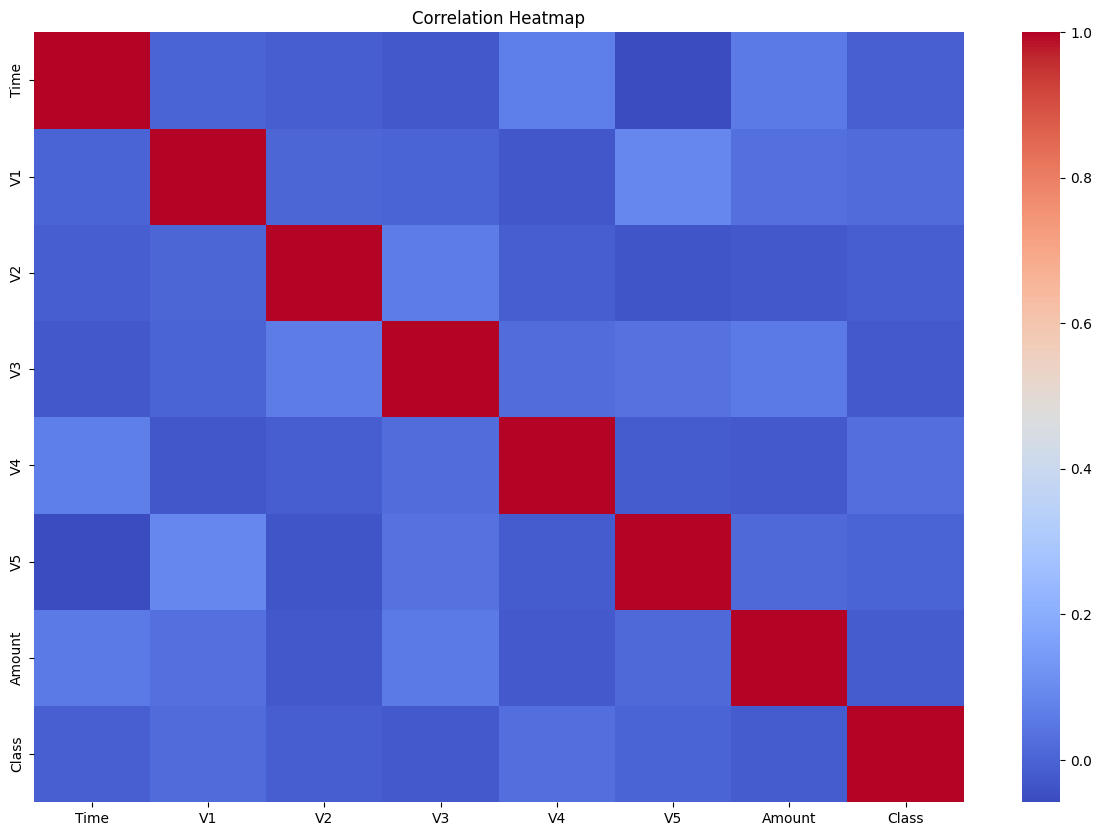

In [29]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

8: RISK ANALYSIS

CREATE RISK LEVELS


In [30]:
def risk_category(amount):

    if amount < 100:
        return 'Low Risk'

    elif amount < 1000:
        return 'Medium Risk'

    else:
        return 'High Risk'

df['Risk_Level'] = df['Amount'].apply(risk_category)

df[['Amount','Risk_Level']].head()

,Amount,Risk_Level
0,1600.89,High Risk
1,4191.85,High Risk
2,3271.32,High Risk
3,1377.51,High Risk
4,4838.72,High Risk


RISK LEVEL COUNT


In [31]:
df['Risk_Level'].value_counts()


,count
Risk_Level,
High Risk,811
Medium Risk,171
Low Risk,18


RISK LEVEL VISUALIZATION

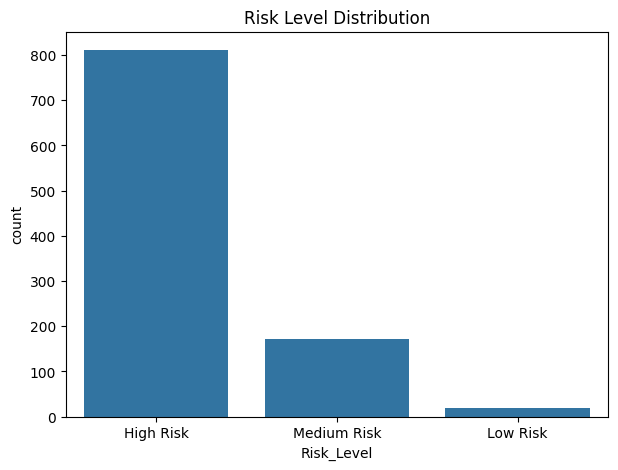

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(x='Risk_Level', data=df)

plt.title('Risk Level Distribution')

plt.show()

9: PREDICTIVE MODELING (LINEAR REGRESSION)


DEFINE X AND Y VARIABLES


In [33]:
X = df[['Time']]
y = df['Amount']


TRAIN TEST SPLIT


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


BUILD LINEAR REGRESSION MODEL


In [36]:
model = LinearRegression()

TRAIN MODEL

In [37]:
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


MAKE PREDICTIONS

In [38]:
y_pred = model.predict(X_test)

print(y_pred[:10])


[2465.0849162  2519.93269242 2581.45241085 2489.22705422 2685.67807345
 2645.97909827 2755.6820027  2746.08396351 2630.86338125 2577.30036747]


10: MODEL EVALUATION

R2 SCORE

In [39]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)


R2 Score : -0.006739288518918141


 ERROR METRICS


In [40]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)


Mean Absolute Error : 1213.997695593687
Mean Squared Error : 1956045.9695279659


RESIDUAL ANALYSIS


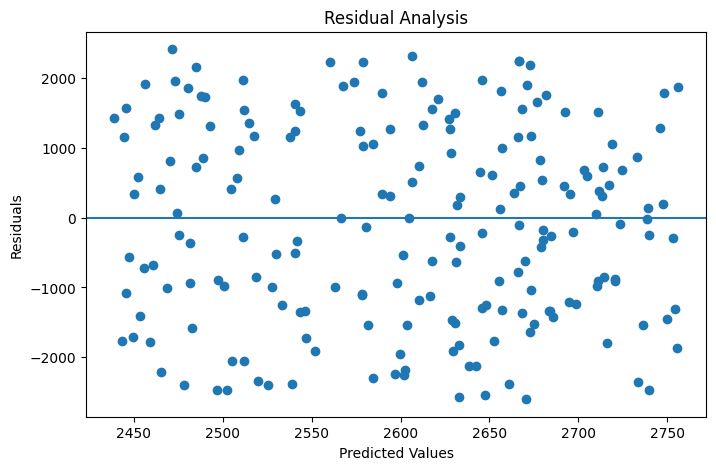

In [41]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.title('Residual Analysis')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')

plt.show()

 11: DASHBOARD CREATION

 INTERACTIVE FRAUD DISTRIBUTION

In [42]:
fig = px.histogram(
    df,
    x='Class',
    title='Fraud Distribution'
)

fig.show()


 INTERACTIVE AMOUNT TREND

In [43]:
fig = px.line(
    df.head(1000),
    x='Time',
    y='Amount',
    title='Transaction Amount Trend'
)

fig.show()

 INTERACTIVE FRAUD COMPARISON

In [44]:
fig = px.box(
    df,
    x='Class',
    y='Amount',
    title='Fraud vs Amount'
)

fig.show()

RISK LEVEL DASHBOARD

In [47]:
fig = px.pie(
    df,
    names='Risk_Level',
    title='Risk Level Distribution'
)

fig.show()

12: INSIGHTS & CONCLUSION

In [50]:
print("1. Fraud transactions are very low compared to normal transactions.")

print("2. High transaction amounts show higher fraud risk.")

print("3. Correlation analysis helps identify important fraud-related features.")

print("4. Risk categorization helps banks identify suspicious transactions quickly.")

print("5. Visualization improves understanding of transaction behavior.")


print("FINAL CONCLUSION")
print()

print("The Credit Card Fraud Detection System helps analyze")
print("transaction behavior using EDA, visualization,")
print("risk analysis, and Linear Regression modeling.")

print()

print("This project supports fraud prevention strategies")
print("and helps financial institutions improve security.")

1. Fraud transactions are very low compared to normal transactions.
2. High transaction amounts show higher fraud risk.
3. Correlation analysis helps identify important fraud-related features.
4. Risk categorization helps banks identify suspicious transactions quickly.
5. Visualization improves understanding of transaction behavior.
FINAL CONCLUSION

The Credit Card Fraud Detection System helps analyze
transaction behavior using EDA, visualization,
risk analysis, and Linear Regression modeling.

This project supports fraud prevention strategies
and helps financial institutions improve security.
